# 🏥 Medical RAG Chatbot
### LangChain · LangGraph · **Google Gemini** · Wikipedia · FAISS

---

| Component | Technology |
|-----------|------------|
| 🤖 LLM | `Gemini 1.5 Flash` — Google AI API |
| 🧠 Embeddings | `sentence-transformers/all-MiniLM-L6-v2` (local) |
| 📚 Vector Store | FAISS (in-memory) |
| 🌐 Knowledge Base | Wikipedia via `wikipedia-api` |
| 🔗 Orchestration | LangGraph ReAct Agent |
| 🔧 Tools | RAG Retriever · Live Wikipedia · Symptom Checker |

## 📦 Step 1 — Install Dependencies

In [1]:
!pip install -q \
    langchain \
    langchain-core \
    langchain-community \
    langchain-google-genai \
    google-generativeai \
    langchain-huggingface \
    langgraph \
    sentence-transformers \
    faiss-cpu \
    wikipedia-api \
    python-dotenv \
    tiktoken \
    ipywidgets

print('✅ All packages installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 135.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires request

## 🔑 Step 2 — Google Gemini API Key
> Get a **free** key → **https://aistudio.google.com/app/apikey**

> ✅ Free tier: **1500 requests/day** — no credit card needed

In [2]:
import os
from getpass import getpass

GEMINI_API_KEY = getpass('🔑 Enter your Google Gemini API key: ')
os.environ['GOOGLE_API_KEY'] = GEMINI_API_KEY

print('✅ Gemini API key loaded successfully!')

🔑 Enter your Google Gemini API key: ··········
✅ Gemini API key loaded successfully!


In [3]:
import google.generativeai as genai

genai.configure(api_key=os.environ["GOOGLE_API_KEY"])

models = genai.list_models()

for m in models:
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/antigravity-preview-05-2026
models/

## 📥 Step 3 — Imports

In [4]:
import os
from typing import Annotated, List
from typing_extensions import TypedDict
from IPython.display import display, Image

# ✅ Gemini LLM
from langchain_google_genai import ChatGoogleGenerativeAI

# Embeddings (local, free, no API needed)
from langchain_huggingface import HuggingFaceEmbeddings

# LangChain core
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import create_retriever_tool, tool
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

# LangGraph
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

print('✅ All imports successful!')

/tmp/ipykernel_467/3423868246.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS
/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


✅ All imports successful!


## 📚 Step 4 — Load Wikipedia Medical Knowledge Base

In [5]:
import wikipediaapi
from time import sleep

wiki = wikipediaapi.Wikipedia(language='en', user_agent='MediBot/1.0')

MEDICAL_TOPICS = [
    # Diseases
    'Diabetes mellitus', 'Hypertension', 'COVID-19', 'Cancer', 'Asthma',
    'Tuberculosis', 'Pneumonia', 'Influenza', 'Dengue fever', 'Malaria',
    'Heart disease', 'Stroke', 'Kidney failure', 'Liver disease', 'Obesity',
    'Anemia', 'Arthritis', 'Migraine', 'Epilepsy',
    "Parkinson's disease", "Alzheimer's disease",
    # Anatomy
    'Human body', 'Brain', 'Heart', 'Lung', 'Kidney', 'Liver',
    'Digestive system', 'Nervous system', 'Immune system',
    'Respiratory system', 'Circulatory system', 'Endocrine system',
    # Symptoms
    'Fever', 'Cough', 'Chest pain', 'Headache', 'Fatigue',
    'Shortness of breath', 'Abdominal pain', 'Diarrhea', 'Weight loss',
    # Medicines & Treatments
    'Antibiotic', 'Vaccination', 'Insulin', 'Chemotherapy',
    'Paracetamol', 'Ibuprofen', 'Pain management',
    # Health
    'Nutrition', 'Vitamin', 'Mental health', 'Exercise', 'Public health'
]

def fetch_medical_page(title):
    try:
        page = wiki.page(title)
        if page.exists():
            return Document(
                page_content=page.text[:5000],
                metadata={'title': page.title, 'source': page.fullurl}
            )
        return None
    except Exception as e:
        print(f'Error loading {title}: {e}')
        return None

all_docs = []
print(' Loading Medical Knowledge Base...\n')

for topic in MEDICAL_TOPICS:
    doc = fetch_medical_page(topic)
    if doc:
        all_docs.append(doc)
        print(f'Loaded: {topic}')
    else:
        print(f' Skipped: {topic}')
    sleep(0.3)

print(f'\n📦 Total Documents Loaded: {len(all_docs)}')

 Loading Medical Knowledge Base...

Loaded: Diabetes mellitus
Loaded: Hypertension
Loaded: COVID-19
Loaded: Cancer
Loaded: Asthma
Loaded: Tuberculosis
Loaded: Pneumonia
Loaded: Influenza
Loaded: Dengue fever
Loaded: Malaria
Loaded: Heart disease
Loaded: Stroke
Loaded: Kidney failure
Loaded: Liver disease
Loaded: Obesity
Loaded: Anemia
Loaded: Arthritis
Loaded: Migraine
Loaded: Epilepsy
Loaded: Parkinson's disease
Loaded: Alzheimer's disease
Loaded: Human body
Loaded: Brain
Loaded: Heart
Loaded: Lung
Loaded: Kidney
Loaded: Liver
Loaded: Digestive system
Loaded: Nervous system
Loaded: Immune system
Loaded: Respiratory system
Loaded: Circulatory system
Loaded: Endocrine system
Loaded: Fever
Loaded: Cough
Loaded: Chest pain
Loaded: Headache
Loaded: Fatigue
Loaded: Shortness of breath
Loaded: Abdominal pain
Loaded: Diarrhea
Loaded: Weight loss
Loaded: Antibiotic
Loaded: Vaccination
Loaded: Insulin
Loaded: Chemotherapy
Loaded: Paracetamol
Loaded: Ibuprofen
Loaded: Pain management
Loaded: Nut

## 🧠 Step 4.5 — Build FAISS Vector Store

In [6]:
if len(all_docs) == 0:
    raise ValueError(' No documents loaded. Check Wikipedia connection.')

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=80)
chunks = splitter.split_documents(all_docs)
print(f' {len(all_docs)} articles → {len(chunks)} chunks')

print('\n Loading embedding model (runs locally, no API needed)...')
embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

print('\n Building FAISS index...')
vectorstore = FAISS.from_documents(documents=chunks, embedding=embeddings)
print(f' FAISS ready — {vectorstore.index.ntotal} vectors indexed!')

 54 articles → 842 chunks

 Loading embedding model (runs locally, no API needed)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


 Building FAISS index...
 FAISS ready — 842 vectors indexed!


In [7]:
results = vectorstore.similarity_search('symptoms of hypertension', k=2)
print('🔍 Retrieval test: "symptoms of hypertension"\n')
for i, doc in enumerate(results, 1):
    print(f'--- Result {i}: {doc.metadata.get("title", "")} ---')
    print(doc.page_content[:300])
    print()

🔍 Retrieval test: "symptoms of hypertension"

--- Result 1: Hypertension ---
Signs and symptoms
Hypertension is rarely accompanied by symptoms. Half of all people with hypertension are unaware that they have it. Hypertension is usually identified as part of health screening or when seeking healthcare for an unrelated problem.

--- Result 2: Hypertension ---
of hypertension accompanied by headache, palpitations, pale appearance, and excessive sweating.



## 🔧 Step 5 — Define Tools

| # | Tool | Purpose |
|---|------|---------|
| 1 | `medical_rag_retriever` | FAISS local knowledge base |
| 2 | `wikipedia_live_tool` | Live Wikipedia search (fallback) |
| 3 | `symptom_checker` | Rule-based symptom mapper |

In [8]:
import wikipediaapi

# ── Tool 1: RAG Retriever ──────────────────────────────────────
retriever = vectorstore.as_retriever(search_kwargs={'k': 5})
rag_tool = create_retriever_tool(
    retriever,
    name='medical_rag_retriever',
    description=(
        'Search the local medical knowledge base built from Wikipedia. '
        'Use this FIRST for any medical question about diseases, symptoms, '
        'treatments, medications, anatomy, or health conditions.'
    ),
)
print('✅ Tool 1: medical_rag_retriever')

# ── Tool 2: Live Wikipedia ─────────────────────────────────────
@tool
def wikipedia_live_tool(query: str) -> str:
    """Search Wikipedia live for medical information not in the local knowledge base."""
    wiki_client = wikipediaapi.Wikipedia(language='en', user_agent='MediBot/1.0')
    try:
        page = wiki_client.page(query)
        if page.exists():
            return page.text[:3000]
        return f"No Wikipedia page found for '{query}'."
    except Exception as e:
        return f'Wikipedia search error: {e}'

print('✅ Tool 2: wikipedia_live_tool')

# ── Tool 3: Symptom Checker ────────────────────────────────────
@tool
def symptom_checker(symptoms: str) -> str:
    """Given a comma-separated list of symptoms, return possible medical conditions."""
    symptom_map = {
        'fever':               ['Influenza', 'COVID-19', 'Malaria', 'Typhoid'],
        'cough':               ['Asthma', 'COVID-19', 'Tuberculosis', 'Bronchitis'],
        'chest pain':          ['Heart disease', 'Angina', 'Pneumonia', 'GERD'],
        'headache':            ['Migraine', 'Hypertension', 'Tension headache', 'Meningitis'],
        'fatigue':             ['Anemia', 'Diabetes', 'Hypothyroidism', 'Depression'],
        'shortness of breath': ['Asthma', 'Heart failure', 'COVID-19', 'Pulmonary embolism'],
        'frequent urination':  ['Diabetes mellitus', 'UTI', 'Diabetes insipidus'],
        'weight loss':         ['Diabetes', 'Cancer', 'Tuberculosis', 'Hyperthyroidism'],
        'joint pain':          ['Arthritis', 'Gout', 'Lupus', 'Fibromyalgia'],
        'rash':                ['Eczema', 'Psoriasis', 'Allergic reaction', 'Lupus'],
        'nausea':              ['Gastritis', 'Food poisoning', 'Pregnancy', 'Migraine'],
        'dizziness':           ['Hypertension', 'Anemia', 'Inner ear disorder', 'Dehydration'],
        'vomiting':            ['Gastritis', 'Food poisoning', 'Appendicitis', 'Migraine'],
        'abdominal pain':      ['Gastritis', 'Appendicitis', 'IBS', 'Kidney stones'],
        'back pain':           ['Muscle strain', 'Herniated disc', 'Kidney stones', 'Sciatica'],
    }
    entered = [s.strip().lower() for s in symptoms.split(',')]
    result = {}
    for sym in entered:
        for key, conditions in symptom_map.items():
            if key in sym:
                result[key] = conditions
    if not result:
        return 'No specific matches found. Please describe symptoms more clearly or consult a healthcare professional.'
    lines = [' Possible conditions (educational only):\n']
    for sym, conds in result.items():
        lines.append(f'  • {sym.capitalize()}: {", ".join(conds)}')
    lines.append('\n Always consult a licensed physician for proper diagnosis.')
    return '\n'.join(lines)

print('✅ Tool 3: symptom_checker')

tools = [rag_tool, wikipedia_live_tool, symptom_checker]
print(f'\n {len(tools)} tools ready!')

✅ Tool 1: medical_rag_retriever
✅ Tool 2: wikipedia_live_tool
✅ Tool 3: symptom_checker

 3 tools ready!


## 🤖 Step 6 — Build LangGraph Agent

```
START → [agent] → has tool_calls? → YES → [tools] → back to [agent]
                                  → NO  → END
```

> ✅ **Using Gemini 1.5 Flash** — fast, free, supports tool calling natively

In [22]:
# ============================================================
# IMPORTS
# ============================================================

import os
from typing import List
from typing_extensions import TypedDict, Annotated

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    SystemMessage
)

# ✅ GEMINI — replaces TinyLlama local pipeline
from langchain_google_genai import ChatGoogleGenerativeAI

# ============================================================
# SYSTEM PROMPT
# ============================================================

SYSTEM_PROMPT = """
You are MediBot, an expert Medical AI Assistant.

Your job is to answer medical questions clearly,
accurately, and in detail.

Your have access to these tools:

1. medical_rag_retriever
   → search the local FAISS knowledge base

2. wikipedia_live_tool
   → search Wikipedia live

3. symptom_checker
   → map symptoms to conditions

STRICT RULES:

- ALWAYS use medical_rag_retriever first.
- Use symptom_checker if symptoms are mentioned.
- Use wikipedia_live_tool for extra details.
- Give structured and detailed answers.
- Mention tools used at the end.

Always end with:

⚠️ For informational purposes only.
Always consult a healthcare professional.
"""

# ============================================================
# STATE
# ============================================================

class AgentState(TypedDict):
    messages:   Annotated[list, add_messages]
    tools_used: List[str]

# ============================================================
# ✅ GEMINI 1.5 FLASH LLM
#
#  WHY GEMINI INSTEAD OF TINYLLAMA:
#   • TinyLlama ran on CPU  → 30–120s per response
#   • Gemini runs on Google servers → 1–3s per response
#   • Much smarter & more accurate for medical Q&A
#   • Native tool calling support (required for LangGraph)
#   • FREE: 1500 requests/day at aistudio.google.com
# ============================================================

# Initialize the LangChain Gemini LLM
print("⏳ Initializing Gemini LLM for LangChain...")
llm = ChatGoogleGenerativeAI(model="gemini-flash-latest", temperature=0)

# A simple test call to verify initialization (optional)
try:
    test_response = llm.invoke("What is diabetes mellitus?")
    print(f"✅ Gemini LLM initialized and test call successful: {test_response.content[:50]}...")
except Exception as e:
    print(f"❌ Error during Gemini LLM initialization or test call: {e}")

# ============================================================
# BIND TOOLS
# ============================================================

llm_with_tools = llm.bind_tools(tools)

tool_node = ToolNode(tools)

# ============================================================
# AGENT NODE
# ============================================================

def call_model(state: AgentState):
    msgs = list(state["messages"])
    if not any(isinstance(m, SystemMessage) for m in msgs):
        msgs = [SystemMessage(content=SYSTEM_PROMPT)] + msgs
    response = llm_with_tools.invoke(msgs)
    return {"messages": [response]}

# ============================================================
# TOOL NODE
# ============================================================

def run_tools(state: AgentState):
    last = state["messages"][-1]
    used = list(state.get("tools_used", []))
    if hasattr(last, "tool_calls") and last.tool_calls:
        for tc in last.tool_calls:
            name = tc.get("name", "unknown")
            if name not in used:
                used.append(name)
    result = tool_node.invoke(state)
    result["tools_used"] = used
    return result

# ============================================================
# ROUTING
# ============================================================

def should_continue(state: AgentState):
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tools"
    return END

# ============================================================
# BUILD GRAPH
# ============================================================

graph = StateGraph(AgentState)
graph.add_node("agent", call_model)
graph.add_node("tools", run_tools)
graph.set_entry_point("agent")
graph.add_conditional_edges(
    "agent",
    should_continue,
    {"tools": "tools", END: END}
)
graph.add_edge("tools", "agent")

# ============================================================
# COMPILE AGENT
# ============================================================

agent = graph.compile()
print("✅ LangGraph Medical Agent with Gemini compiled successfully!")

⏳ Initializing Gemini LLM for LangChain...
✅ Gemini LLM initialized and test call successful: [{'type': 'text', 'text': '**Diabetes mellitus** (often simply called **diabetes**) is a chronic, long-term health condition that affects how your body turns food into energy. \n\nNormally, your body breaks down the food you eat into sugar (glucose) and releases it into your bloodstream. When your blood sugar goes up, it signals your pancreas to release **insulin**. Insulin acts like a "key" that lets the blood sugar into your body’s cells for use as energy.\n\nIf you have diabetes, your body either **doesn’t make enough insulin** or **can’t use the insulin it makes** as well as it should. When there isn’t enough insulin, or cells stop responding to insulin, too much blood sugar stays in your bloodstream. Over time, this can cause serious health problems.\n\n---\n\n### The Main Types of Diabetes\n\nThere are three primary types of diabetes:\n\n#### 1. Type 1 Diabetes\n*   **What it is:** An au

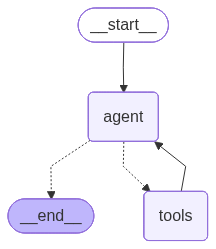

In [23]:
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    print(agent.get_graph().draw_ascii())

## 💬 Step 7 — Chat Helper

In [24]:
TOOL_LABELS = {
    'medical_rag_retriever': ' RAG Retriever (FAISS)',
    'wikipedia_live_tool':   ' Live Wikipedia',
    'symptom_checker':       ' Symptom Checker',
}

conversation_history = []

def ask_medibot(question: str):
    global conversation_history
    conversation_history.append(HumanMessage(content=question))

    try:
        result = agent.invoke(
            {'messages': conversation_history, 'tools_used': []},
            config={'recursion_limit': 20},
        )
    except Exception as e:
        print(f' Agent error: {e}')
        return

    ai_msgs = [m for m in result['messages'] if isinstance(m, AIMessage)]
    if not ai_msgs:
        print(' No AI response received.')
        return

    final_msg = ai_msgs[-1]
    reply = final_msg.content if isinstance(final_msg.content, str) else str(final_msg.content)
    tools_used = result.get('tools_used', [])
    conversation_history.append(final_msg)

    print('\n' + '=' * 80)
    print(f'🧑 You: {question}')
    print('\n MediBot:')
    print(reply)
    print('\n Tools Used:', ', '.join(TOOL_LABELS.get(t, t) for t in tools_used) if tools_used else 'None')
    print('=' * 80)

def reset_conversation():
    global conversation_history
    conversation_history = []
    print('🔄 Conversation cleared.')

print('MediBot ready! Call ask_medibot("your question") to start.')

MediBot ready! Call ask_medibot("your question") to start.


## 🧪 Step 8 — Demo Queries

In [26]:
ask_medibot('What is diabetes mellitus and how is it treated?')


🧑 You: What is diabetes mellitus and how is it treated?

 MediBot:
[{'type': 'text', 'text': '### What is Diabetes Mellitus?\n\n**Diabetes mellitus** (commonly referred to simply as diabetes) is a chronic endocrine and metabolic disorder characterized by sustained high levels of glucose (sugar) in the blood (hyperglycemia). \n\nNormally, when you eat, your body breaks food down into glucose. The pancreas releases a hormone called **insulin**, which acts like a key to let glucose enter your cells to be used for energy. In people with diabetes, this process is disrupted because either the pancreas does not produce enough insulin, or the body\'s cells do not respond effectively to the insulin produced.\n\n#### Classic Symptoms of Diabetes (The "Three Ps"):\n*   **Polydipsia:** Excessive, unquenchable thirst.\n*   **Polyuria:** Frequent urination (especially at night).\n*   **Polyphagia:** Excessive hunger, even after eating.\n*   *Other symptoms include:* Unexplained weight loss, extreme

In [25]:
ask_medibot('I have fever, cough, and fatigue. What could it be?')


🧑 You: I have fever, cough, and fatigue. What could it be?

 MediBot:
[{'type': 'text', 'text': 'The combination of **fever, cough, and fatigue** is a very common set of symptoms. They typically indicate that your immune system is actively fighting off an infection, most commonly affecting the respiratory tract. \n\nHere is a detailed breakdown of the most likely causes, what symptoms to watch out for, and general self-care advice.\n\n---\n\n### 1. Most Common Potential Causes\n\n*   **Influenza (The Flu):** \n    *   *Characteristics:* Symptoms usually appear very suddenly. \n    *   *Associated Symptoms:* High fever, severe muscle or body aches, headache, dry cough, sore throat, and profound fatigue that can last for weeks.\n*   **COVID-19:** \n    *   *Characteristics:* Symptoms can range from mild to severe and appear 2 to 14 days after exposure.\n    *   *Associated Symptoms:* Fever, dry cough, fatigue, loss of taste or smell, sore throat, congestion, and sometimes shortness of b

## ✏️ Step 9 — Ask Your Own Question

In [27]:
ask_medibot('What are the side effects of antibiotics?')


🧑 You: What are the side effects of antibiotics?

 MediBot:
[{'type': 'text', 'text': 'While antibiotics are essential and life-saving medications used to treat bacterial infections, they can cause a range of side effects. This happens because antibiotics can affect healthy cells and disrupt the beneficial bacteria (microbiome) living in your body.\n\nThe side effects of antibiotics range from mild and common to rare and severe.\n\n---\n\n### 1. Common Side Effects (Mild to Moderate)\nThese side effects are usually temporary and resolve once the course of antibiotics is completed.\n\n*   **Gastrointestinal (GI) Issues:** This is the most common side effect. Because antibiotics kill both "bad" and "good" gut bacteria, they frequently cause:\n    *   Diarrhea\n    *   Nausea and vomiting\n    *   Bloating, gas, and abdominal cramps\n    *   Loss of appetite\n*   **Fungal (Yeast) Infections:** Beneficial bacteria normally keep yeast populations in check. When antibiotics destroy these ba

In [ ]:
reset_conversation()

🔄 Conversation cleared.


## 🖥️ Step 10 — Interactive Chat Widget

> Type any medical question and press **Ask MediBot** or hit Enter.

In [28]:
import ipywidgets as widgets
from IPython.display import clear_output

reset_conversation()

# ── UI Components ──────────────────────────────────────────────
header     = widgets.HTML('<h2 style="color:#2c7be5;">🏥 MediBot — Medical AI Assistant (Gemini)</h2>')
txt_input  = widgets.Text(
    placeholder='Type your medical question here...',
    layout=widgets.Layout(width='70%')
)
btn_ask    = widgets.Button(description='Ask MediBot', button_style='primary',
                            layout=widgets.Layout(width='15%'))
btn_clear  = widgets.Button(description='Clear', button_style='warning',
                            layout=widgets.Layout(width='10%'))
out        = widgets.Output(layout=widgets.Layout(
    border='1px solid #ddd', padding='10px',
    min_height='200px', max_height='600px',
    overflow_y='auto'
))
status_lbl = widgets.Label(value='')

# ── Event Handlers ─────────────────────────────────────────────
def on_ask(b):
    q = txt_input.value.strip()
    if not q:
        return
    txt_input.value = ''
    btn_ask.disabled = True
    status_lbl.value = 'MediBot is thinking...'
    with out:
        ask_medibot(q)
    btn_ask.disabled = False
    status_lbl.value = ''

def on_clear(b):
    reset_conversation()
    with out:
        clear_output()
        print('Chat cleared. Start a new conversation!')
    status_lbl.value = ''

btn_ask.on_click(on_ask)
btn_clear.on_click(on_clear)
txt_input.on_submit(on_ask)

# ── Layout ─────────────────────────────────────────────────────
display(
    header,
    widgets.HBox([txt_input, btn_ask, btn_clear]),
    status_lbl,
    out
)

with out:
    print('👋 Welcome to MediBot! Ask me anything about health and medicine.')
    print('   Examples:')
    print('   • What is diabetes and how is it treated?')
    print('   • I have fever, cough, and fatigue — what could it be?')
    print('   • What are the side effects of ibuprofen?')

🔄 Conversation cleared.


HTML(value='<h2 style="color:#2c7be5;">🏥 MediBot — Medical AI Assistant (Gemini)</h2>')

Label(value='')

Output(layout=Layout(border='1px solid #ddd', max_height='600px', min_height='200px', overflow_y='auto', paddi…

In [ ]:
from google.colab import drive
drive.mount('/content/drive')